In [2]:
library(Seurat)
library(SeuratWrappers)
library(dplyr)
library(ggplot2)
library(usethis)
library(devtools)
library(harmony)
library(patchwork)
library(ggplot2)
library(gridExtra)
library(jcolors)
library(MetBrewer)
library(readxl)

options(repr.plot.width = 14, repr.plot.height = 28)


Warning message:
“package ‘Seurat’ was built under R version 4.5.2”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.5.2”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.5.2”

Attaching package: ‘sp’


The following object is masked from ‘package:IRanges’:

    %over%


‘SeuratObject’ was built with package ‘Matrix’ 1.7.4 but the current
version is 1.7.5; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:IRanges’:

    intersect


The following object is masked from ‘package:S4Vectors’:

    intersect


The following object is masked from ‘package:BiocGenerics’:

    intersect


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘dplyr’ was built under R version 4.5.2”

Attaching package: ‘dplyr’


The following obj

In [1]:
# Libraries for pathway analysis

library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)

Warning message:
“package ‘clusterProfiler’ was built under R version 4.5.3”


clusterProfiler v4.18.4 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu, Li-Gen Wang, Yanyan Han and Qing-Yu He.
clusterProfiler: an R package for comparing biological themes among
gene clusters. OMICS: A Journal of Integrative Biology. 2012,
16(5):284-287


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter


Loading required package: AnnotationDbi

Warning message:
“package ‘AnnotationDbi’ was built under R version 4.5.2”
Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQ

In [7]:
setwd("~/Documents/1 - Projects/Jain Lab/Morphodynamics paper/data")
timecourse <- readRDS("Timecourse.rds")

###  Only ECM-related marker genes per cell type

In [8]:
# Akansha's list
ecm_genes <- read_excel("~/Documents/1 - Projects/Jain Lab/Morphodynamics paper/data/presel_genes.xlsx", sheet = 2)
ecm_genes_list <- unique(na.omit(unlist(ecm_genes)))

# Your list
nick_ecm <- read_excel("/Users/nickmahtani/Documents/1 - Projects/Jain Lab/Mechanotransduction/data/ECM_Gene_Set_Curated.xlsx")
nick_ecm_genes <- unique(na.omit(nick_ecm$`Gene Symbol`))

# Combined
all_ecm_genes <- unique(c(ecm_genes_list, nick_ecm_genes))


In [5]:
length(all_ecm_genes)

[1] 487

In [9]:
Idents(timecourse) <- "class3"
cell_types <- unique(timecourse$class3)

all_markers <- list()

for (ct in cell_types) {
  markers <- FindMarkers(
    timecourse,
    ident.1 = ct,
    only.pos = TRUE,
    min.pct = 0.25,
    logfc.threshold = log(1.2)
  )
  
  markers$gene <- rownames(markers)
  
  all_markers[[ct]] <- markers %>%
    filter(gene %in% all_ecm_genes) %>%
    mutate(specificity = pct.1 / pct.2) %>%
    arrange(desc(specificity))
}


### GO analysis

In [23]:
# Convert gene symbols to Entrez IDs and run GO enrichment per cell type:

go_results <- list()

for (ct in names(all_markers)) {
  genes <- all_markers[[ct]]$gene
  
  if (length(genes) < 3) next  # skip cell types with too few genes
  
  # Convert symbols to Entrez IDs
  gene_ids <- bitr(genes, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)
  
  if (nrow(gene_ids) < 3) next
  
  # Run GO enrichment (Biological Process)
  go <- enrichGO(
    gene = gene_ids$ENTREZID,
    OrgDb = org.Hs.eg.db,
    ont = "BP",
    pAdjustMethod = "BH",
    pvalueCutoff = 0.05,
    readable = TRUE
  )
  
  if (!is.null(go) && nrow(go) > 0) {
    go_results[[ct]] <- go
  }
}


'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(genes, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db):
“1.47% of input gene IDs are fail to map...”
'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



In [28]:
cat(all_markers[["Neurectoderm"]]$gene, sep = ", ")


HAS3, FERMT1, TEAD4, SPP1, PCDH1, CDH3, MT2A, IGFBP4, CDH1, MT1X, WWC1, BCAR1, ZYX, AMOTL1, HMMR, ITGB5, NF2, HAPLN3, PXN, SRF, COL18A1, COL6A2, ITGA6, TLN1, SDC4, SDC1, DSG2, COL26A1, DSC2, TLN2, KRT18, LMNB2, TEAD2, FLNB, CRK, GPC4, YAP1, HYAL2, VCL, KRT19, SAV1, DCTN1, FERMT2, MYH9, LMNB1, FLNA, VCAN, MYH10, ITGB1, C1QBP, RHOA, RAC1, ACTB

In [20]:
  gene_ids <- bitr(genes, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)


'select()' returned 1:1 mapping between keys and columns



In [22]:
length(gene_ids)

[1] 2

In [24]:
for (ct in names(go_results)) {
  cat("\n===", ct, "===\n")
  print(head(as.data.frame(go_results[[ct]]), 10))
}



=== Neurectoderm ===
                   ID                                Description GeneRatio
GO:0031589 GO:0031589                    cell-substrate adhesion     18/53
GO:0031032 GO:0031032          actomyosin structure organization     13/53
GO:0007160 GO:0007160                       cell-matrix adhesion     13/53
GO:0007229 GO:0007229        integrin-mediated signaling pathway     10/53
GO:0042060 GO:0042060                              wound healing     15/53
GO:0045216 GO:0045216            cell-cell junction organization     12/53
GO:0010810 GO:0010810      regulation of cell-substrate adhesion     12/53
GO:0030038 GO:0030038 contractile actin filament bundle assembly      9/53
GO:0043149 GO:0043149                      stress fiber assembly      9/53
GO:0051017 GO:0051017             actin filament bundle assembly     10/53
             BgRatio RichFactor FoldEnrichment   zScore       pvalue
GO:0031589 369/18860 0.04878049       17.35849 16.84666 4.045383e-18
GO:0031032 215/

In [32]:
for (ct in names(go_results)) {
  cat("\n===", ct, "===\n")
  df <- as.data.frame(go_results[[ct]])[1:10, ]
  print(df %>% select(Description, GeneRatio, FoldEnrichment))
}



=== Neurectoderm ===
                                          Description GeneRatio FoldEnrichment
GO:0031589                    cell-substrate adhesion     18/53       17.35849
GO:0031032          actomyosin structure organization     13/53       21.51645
GO:0007160                       cell-matrix adhesion     13/53       18.80503
GO:0007229        integrin-mediated signaling pathway     10/53       30.41445
GO:0042060                              wound healing     15/53       11.78308
GO:0045216            cell-cell junction organization     12/53       18.89464
GO:0010810      regulation of cell-substrate adhesion     12/53       18.56604
GO:0030038 contractile actin filament bundle assembly      9/53       27.60898
GO:0043149                      stress fiber assembly      9/53       27.60898
GO:0051017             actin filament bundle assembly     10/53       21.05616

=== Late Neurectoderm ===
                                           Description GeneRatio FoldEnrichment
GO

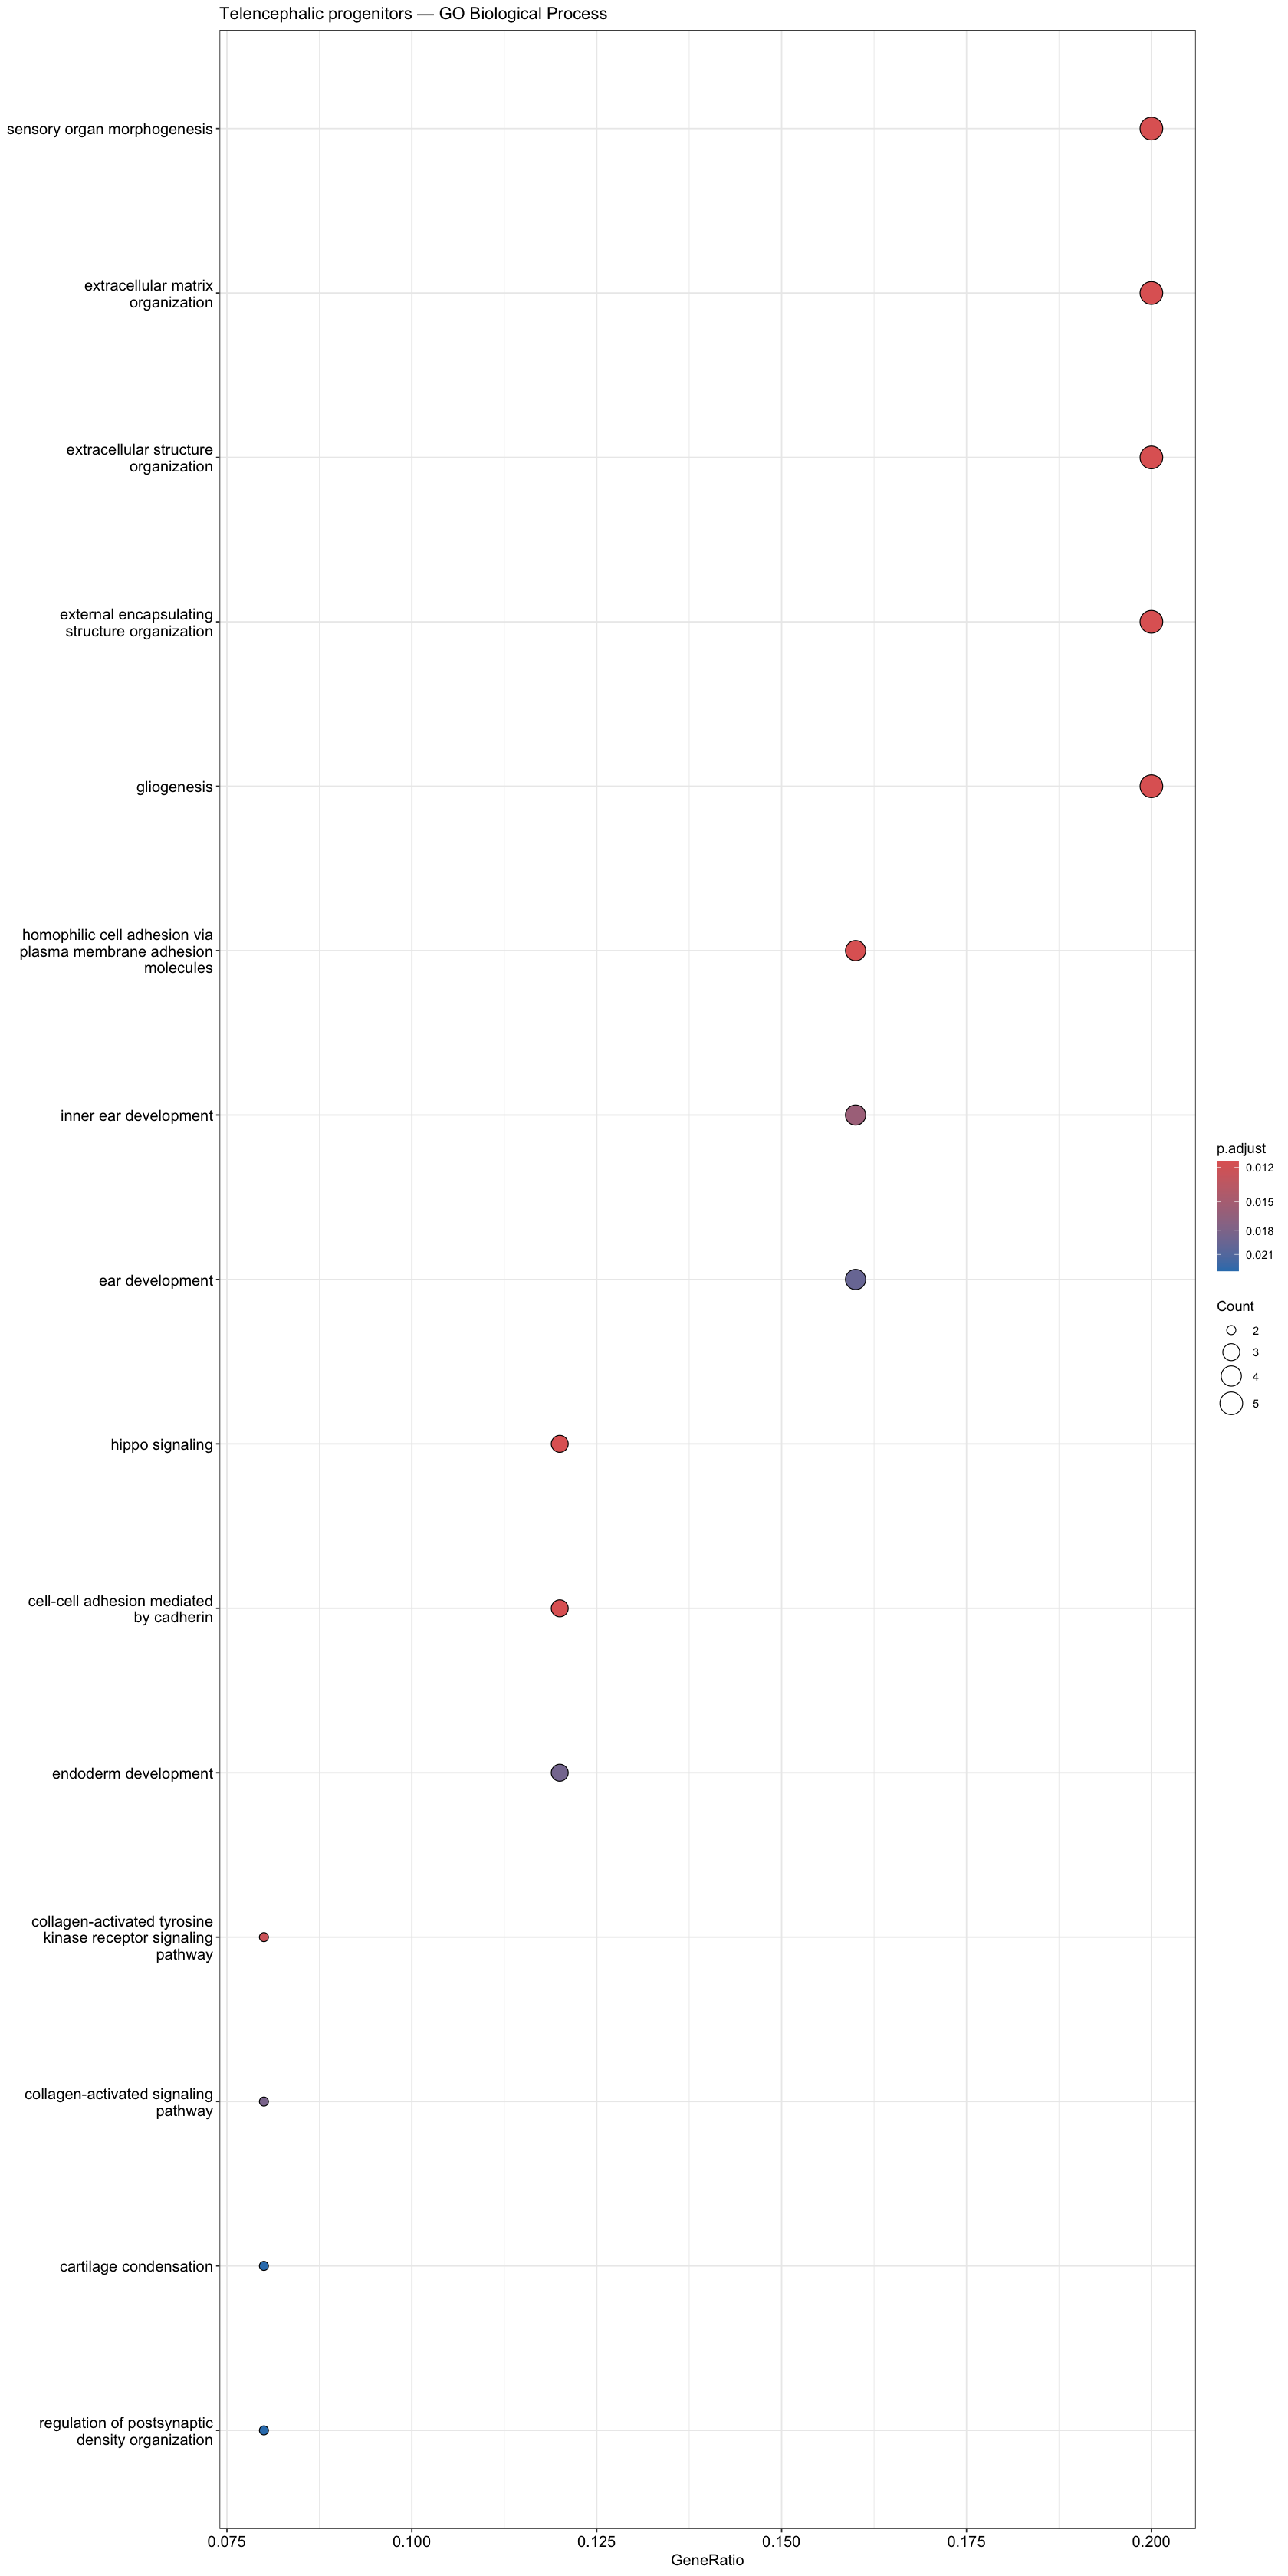

In [ ]:
dotplot(go_results[["Telencephalic progenitors"]], showCategory = 15) +
  ggtitle("Telencephalic progenitors — GO Biological Process")
